In [1]:
import sys
import os
import numpy as np

In [2]:
from datasets import load_from_disk

# If the dataset was saved with save_to_disk()
ds = load_from_disk("D:/Genarative AI/Project/ami_dataset")
print("Dataset loaded:", len(ds))

d:\Genarative AI\Project\diarization_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset loaded: 1085


In [3]:
meeting_id = ds[0]["meeting_id"]

same_meeting = [s for s in ds if s["meeting_id"] == meeting_id]
same_meeting = sorted(same_meeting, key=lambda x: x["begin_time"])
signals = [s["audio"]["array"] for s in same_meeting]
signal = np.concatenate(signals)
sr = same_meeting[0]["audio"]["sampling_rate"]

In [4]:
def preprocess_audio(signal, sr, target_sr=16000):
    if signal.ndim > 1:
        signal = np.mean(signal, axis=1)

    # Resample
    if sr != target_sr:
        signal = librosa.resample(signal, orig_sr=sr, target_sr=target_sr)
        sr = target_sr

    # Normalize safely
    max_val = np.max(np.abs(signal))
    if max_val > 0:
        signal = signal / max_val

    return signal, sr


In [5]:
import webrtcvad
import struct

def float_to_pcm16(signal):
    signal = np.clip(signal, -1, 1)
    signal = (signal * 32767).astype(np.int16)
    return signal

def frame_generator(signal, frame_duration_ms, sr):
    frame_size = int(sr * frame_duration_ms / 1000)

    for i in range(0, len(signal) - frame_size, frame_size):
        start = i / sr
        end = (i + frame_size) / sr
        yield signal[i:i+frame_size], start, end

import webrtcvad
import struct
from collections import deque

def vad_segments(signal, sr, aggressiveness=2):
    vad = webrtcvad.Vad(aggressiveness)

    pcm_signal = float_to_pcm16(signal)
    frame_duration = 30

    frames = list(frame_generator(pcm_signal, frame_duration, sr))

    segments = []
    buffer = deque(maxlen=5)  

    triggered = False
    start_time = 0

    for frame, start, end in frames:
        if len(frame) < int(sr * frame_duration / 1000):
            continue

        frame_bytes = struct.pack('%dh' % len(frame), *frame)
        is_speech = vad.is_speech(frame_bytes, sr)

        buffer.append(is_speech)
        speech_ratio = sum(buffer) / len(buffer)

        if speech_ratio > 0.6:
            if not triggered:
                triggered = True
                start_time = start

        else:
            if triggered:
                segments.append((start_time, end))
                triggered = False

    return segments
def add_padding(segments, max_duration, padding=0.2):
    padded = []
    for start, end in segments:
        start = max(0, start - padding)
        end = min(max_duration, end + padding)
        padded.append((start, end))
    return padded

In [6]:
def filter_short_segments(segments, min_duration=1.0):
    return [
        (start, end)
        for start, end in segments
        if (end - start) >= min_duration
    ]

In [7]:
def merge_and_split_segments(segments, max_len=15.0, gap=0.5):
    merged = []
    current = segments[0]

    for next_seg in segments[1:]:
        if next_seg[0] - current[1] <= gap:
            current = (current[0], next_seg[1])
        else:
            merged.append(current)
            current = next_seg
    merged.append(current)

    # Split long segments
    final_segments = []
    for start, end in merged:
        duration = end - start
        if duration <= max_len:
            final_segments.append((start, end))
        else:
            num_splits = int(np.ceil(duration / max_len))
            for i in range(num_splits):
                s = start + i * max_len
                e = min(start + (i + 1) * max_len, end)
                final_segments.append((s, e))

    return final_segments

In [8]:
from collections import Counter

def smooth_labels(labels, window_size=5):
    smoothed = []

    for i in range(len(labels)):
        start = max(0, i - window_size // 2)
        end = min(len(labels), i + window_size // 2 + 1)

        window = labels[start:end]
        most_common = Counter(window).most_common(1)[0][0]

        smoothed.append(most_common)

    return smoothed

In [9]:
def extract_audio_segments(signal, segments, sr):
    extracted = []

    for start, end in segments:
        start_sample = int(start * sr)
        end_sample = int(end * sr)

        audio_chunk = signal[start_sample:end_sample]

        extracted.append({
            "audio": audio_chunk,
            "start": start,
            "end": end,
            "duration": end - start
        })

    return extracted

In [ ]:
signal, sr = preprocess_audio(signal, sr)

segments = vad_segments(signal, sr)
segments = add_padding(segments, max_duration=len(signal)/sr)
segments = filter_short_segments(segments, min_duration=1.0)
segments = merge_and_split_segments(segments)

speech_audio = extract_audio_segments(signal, segments, sr)

In [11]:
len(segments)

292

In [15]:
import soundfile as sf
import os

os.makedirs("segments", exist_ok=True)

for i, (start, end) in enumerate(segments):
    segment_audio = signal[int(start*sr):int(end*sr)]
    sf.write(f"segments/seg_{i}.wav", segment_audio, sr)

In [11]:
from speechbrain.pretrained import EncoderClassifier
import torch


device = "cuda" if torch.cuda.is_available() else "cpu"

classifier = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir="pretrained_models/spkrec-ecapa",
    run_opts={"device": device}
)
import torch.nn.functional as F
import numpy as np

def extract_speaker_embeddings(segments, sr, min_len=1.0, max_len=10.0):
    embeddings = []

    for seg in segments:
        audio = seg["audio"]

        if len(audio) == 0:
            continue

        duration = len(audio) / sr

        # Pad short segments
        if duration < min_len:
            pad = int((min_len - duration) * sr)
            audio = np.pad(audio, (0, pad))

        # Trim long segments
        if duration > max_len:
            audio = audio[:int(max_len * sr)]

        signal_tensor = torch.tensor(audio).float().unsqueeze(0).to(device)

        with torch.no_grad():
            emb = classifier.encode_batch(signal_tensor)

        emb = emb.squeeze()

        # Normalize (CRITICAL for cosine clustering)
        emb = F.normalize(emb, p=2, dim=0)

        embeddings.append(emb.cpu().numpy())

    return np.array(embeddings)

The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.
d:\Genarative AI\Project\diarization_env\lib\site-packages\speechbrain\utils\torch_audio_backend.py:22: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")
The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.
d:\Genarative AI\Project\diarization_env\lib\site-packages\speechbrain\utils\torch_audio_backend.py:22: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")
d:\Genarative AI\Project\diarization_env\lib\site-packages\speechbrain\utils\checkpoints.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), wh

In [12]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

def estimate_num_speakers(embeddings, max_speakers=8):
    X = embeddings

    if len(X) < 3:
        return 1

    best_k = 2
    best_score = -1

    for k in range(2, min(max_speakers, len(X)) + 1):
        clustering = AgglomerativeClustering(
            n_clusters=k,
            metric='cosine',
            linkage='average'
        )

        labels = clustering.fit_predict(X)

        # Skip bad clustering
        if len(set(labels)) < 2:
            continue

        score = silhouette_score(X, labels, metric='cosine')

        print(f"[INFO] k={k}, silhouette={score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k

    return best_k

In [13]:
def cluster_speakers(embeddings, num_speakers):
    clustering = AgglomerativeClustering(
        n_clusters=num_speakers,
        metric='cosine',
        linkage='average'
    )

    labels = clustering.fit_predict(embeddings)
    return labels

In [14]:
def merge_same_speaker_segments(diarization, gap_threshold=0.5):
    merged = []
    current = diarization[0]

    for next_seg in diarization[1:]:
        if (
            next_seg["speaker"] == current["speaker"] and
            next_seg["start"] - current["end"] <= gap_threshold
        ):
            # Merge
            current["end"] = next_seg["end"]
            current["duration"] = current["end"] - current["start"]
        else:
            merged.append(current)
            current = next_seg

    merged.append(current)
    return merged

In [15]:
def build_diarization_output(segments, labels):
    diarization = []

    for seg, label in zip(segments, labels):
        diarization.append({
            "start": seg["start"],
            "end": seg["end"],
            "speaker": f"SPEAKER_{label}",
            "duration": seg["duration"]
        })

    return diarization

In [16]:
# Step 1: Extract embeddings
embeddings = extract_speaker_embeddings(speech_audio, sr)
print("Embeddings shape:", embeddings.shape)

Embeddings shape: (292, 192)


In [20]:
# Step 2: Estimate speakers
best_k = estimate_num_speakers(embeddings)

print("Best number of speakers:", best_k)


[INFO] k=2, silhouette=0.3538
[INFO] k=3, silhouette=0.3135
[INFO] k=4, silhouette=0.3903
[INFO] k=5, silhouette=0.3861
[INFO] k=6, silhouette=0.3858
[INFO] k=7, silhouette=0.4621
[INFO] k=8, silhouette=0.4393
Best number of speakers: 7


In [21]:
# Step 3: Cluster
labels = cluster_speakers(embeddings, best_k)

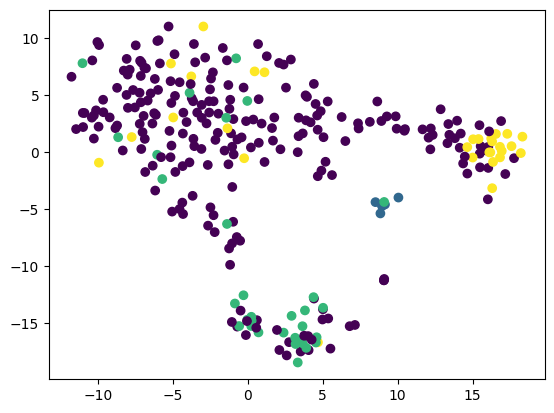

In [24]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X = TSNE(n_components=2).fit_transform(embeddings)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

In [22]:
# Step 4: Build diarization
diarization = build_diarization_output(speech_audio, labels)

# Preview
for d in diarization[:10]:
    print(d)

{'start': 0.46, 'end': 9.29, 'speaker': 'SPEAKER_2', 'duration': 8.829999999999998}
{'start': 11.08, 'end': 13.04, 'speaker': 'SPEAKER_2', 'duration': 1.959999999999999}
{'start': 13.870000000000001, 'end': 16.19, 'speaker': 'SPEAKER_2', 'duration': 2.3200000000000003}
{'start': 16.84, 'end': 31.84, 'speaker': 'SPEAKER_0', 'duration': 15.0}
{'start': 31.84, 'end': 32.6, 'speaker': 'SPEAKER_0', 'duration': 0.7600000000000016}
{'start': 33.55, 'end': 41.18, 'speaker': 'SPEAKER_0', 'duration': 7.630000000000003}
{'start': 41.949999999999996, 'end': 56.27, 'speaker': 'SPEAKER_0', 'duration': 14.320000000000007}
{'start': 57.16, 'end': 72.16, 'speaker': 'SPEAKER_0', 'duration': 15.0}
{'start': 72.16, 'end': 87.16, 'speaker': 'SPEAKER_0', 'duration': 15.0}
{'start': 87.16, 'end': 97.52, 'speaker': 'SPEAKER_0', 'duration': 10.36}


## Using Smoothing labels + Merge same speaker segments

In [22]:
# Step 4: Smooth labels
labels = smooth_labels(labels, window_size=5)

# Step 5: Build diarization
diarization = build_diarization_output(speech_audio, labels)

# Step 6: Merge segments
diarization = merge_same_speaker_segments(diarization)

# Preview
for d in diarization[:10]:
    print(d)

{'start': 0.46, 'end': 9.29, 'speaker': 'SPEAKER_2', 'duration': 8.829999999999998}
{'start': 11.08, 'end': 13.04, 'speaker': 'SPEAKER_2', 'duration': 1.959999999999999}
{'start': 13.870000000000001, 'end': 16.19, 'speaker': 'SPEAKER_2', 'duration': 2.3200000000000003}
{'start': 16.84, 'end': 32.6, 'speaker': 'SPEAKER_0', 'duration': 15.760000000000002}
{'start': 33.55, 'end': 41.18, 'speaker': 'SPEAKER_0', 'duration': 7.630000000000003}
{'start': 41.949999999999996, 'end': 56.27, 'speaker': 'SPEAKER_0', 'duration': 14.320000000000007}
{'start': 57.16, 'end': 97.52, 'speaker': 'SPEAKER_0', 'duration': 40.36}
{'start': 98.08, 'end': 108.05, 'speaker': 'SPEAKER_0', 'duration': 9.969999999999999}
{'start': 108.7, 'end': 149.6, 'speaker': 'SPEAKER_0', 'duration': 40.89999999999999}
{'start': 150.52, 'end': 182.72, 'speaker': 'SPEAKER_0', 'duration': 32.19999999999999}


In [23]:
def get_num_speakers(diarization):
    speakers = {seg["speaker"] for seg in diarization}
    return len(speakers)

num_speakers = get_num_speakers(diarization)

print("Final number of speakers:", num_speakers)

Final number of speakers: 4
